In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

from sklearn import datasets

from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC

## Задание 1
### Загрузка DataFrame

In [2]:
iris_data = datasets.load_iris()
iris = pd.DataFrame(data= iris_data.data,
                    columns= iris_data.feature_names)

iris['class'] = pd.Categorical.from_codes(iris_data.target, iris_data.target_names)

print("Начало датасета ирисов")
iris

Начало датасета ирисов


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


### Нахождение корреляций

In [3]:
print("Общая корреляция ирисов")
iris.corr(numeric_only=True)

Общая корреляция ирисов


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


In [4]:
print("Сгруппированная корреляция по классам ирисов")
iris.groupby("class", observed=True, ).corr(numeric_only=True)

Сгруппированная корреляция по классам ирисов


sepal length (cm)  sepal width (cm)  \
class                                                               
setosa     sepal length (cm)           1.000000          0.742547   
           sepal width (cm)            0.742547          1.000000   
           petal length (cm)           0.267176          0.177700   
           petal width (cm)            0.278098          0.232752   
versicolor sepal length (cm)           1.000000          0.525911   
           sepal width (cm)            0.525911          1.000000   
           petal length (cm)           0.754049          0.560522   
           petal width (cm)            0.546461          0.663999   
virginica  sepal length (cm)           1.000000          0.457228   
           sepal width (cm)            0.457228          1.000000   
           petal length (cm)           0.864225          0.401045   
           petal width (cm)            0.281108          0.537728   

                              petal length (cm)  petal width (cm)  
class                                                              
setosa     sepal length (cm)           0.267176          0.278098  
           sepal width (cm)            0.177700          0.232752  
           petal length (cm)           1.000000          0.331630  
           petal width (cm)            0.331630          1.000000  
versicolor sepal length (cm)           0.754049          0.546461  
           sepal width (cm)            0.560522          0.663999  
           petal length (cm)           1.000000          0.786668  
           petal width (cm)            0.786668          1.000000  
virginica  sepal length (cm)           0.864225          0.281108  
           sepal width (cm)            0.401045          0.537728  
           petal length (cm)           1.000000          0.322108  
           petal width (cm)            0.322108          1.000000

### Графика

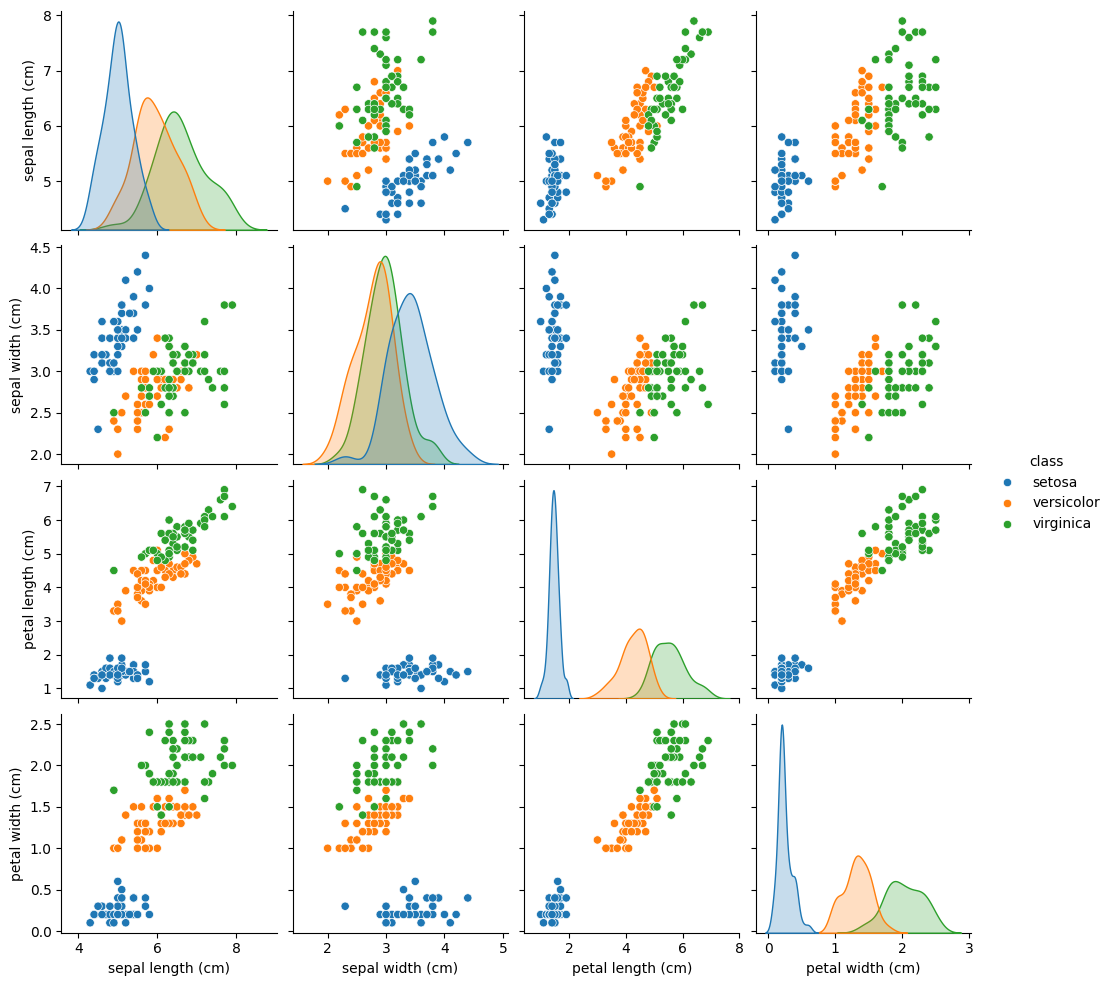

In [5]:
sns.pairplot(iris, hue='class')

## Задание 2

### Подготовка данных

In [6]:
X = iris[['petal length (cm)', 'petal width (cm)']].values
Y, unique_classes = pd.factorize(iris['class'])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.3, random_state=0)

### Функция для визуалиации

In [7]:
def plot_decision_regions(X, Y, classifier, test_idx=None, resolution=0.02):
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(Y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(Y)):
        plt.scatter(x=X[Y == cl, 0], y=X[Y == cl, 1],
                    alpha=0.8, color=cmap(idx),
                    marker=markers[idx], label=cl)

### Решение методом линейного дискриминанта

In [8]:
lda = LinearDiscriminantAnalysis(solver='svd')
lda.fit(X_train, Y_train)

print('Точность на тренировочных данных {:.2f} %'.format(100*lda.score(X_train, Y_train)))
print('Точность на тестовых данных {:.2f} %'.format(100*lda.score(X_test, Y_test)))

Точность на тренировочных данных 95.24 %
Точность на тестовых данных 95.56 %


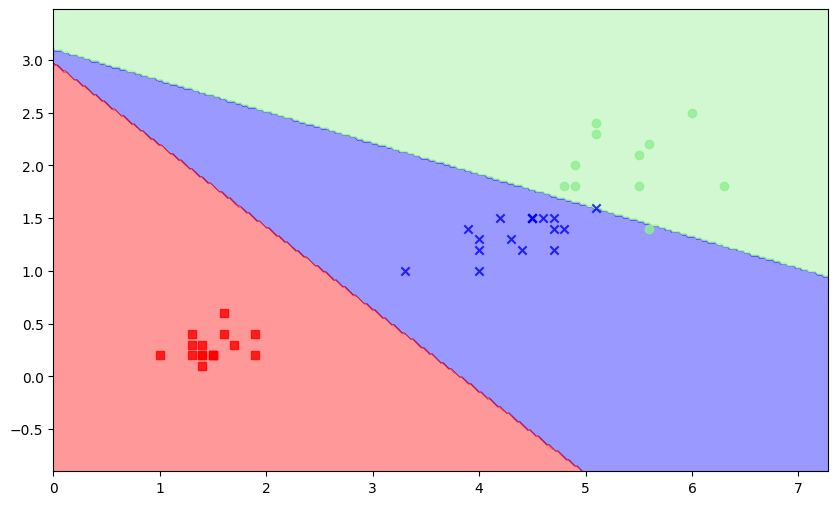

In [9]:
plot_decision_regions(X_test, Y_test, lda)

### Решение методом квадратичного дискриминанта

In [10]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, Y_train)

print('Точность на тренировочных данных {:.2f} %'.format(100*qda.score(X_train, Y_train)))
print('Точность на тестовых данных {:.2f} %'.format(100*qda.score(X_test, Y_test)))

Точность на тренировочных данных 96.19 %
Точность на тестовых данных 100.00 %


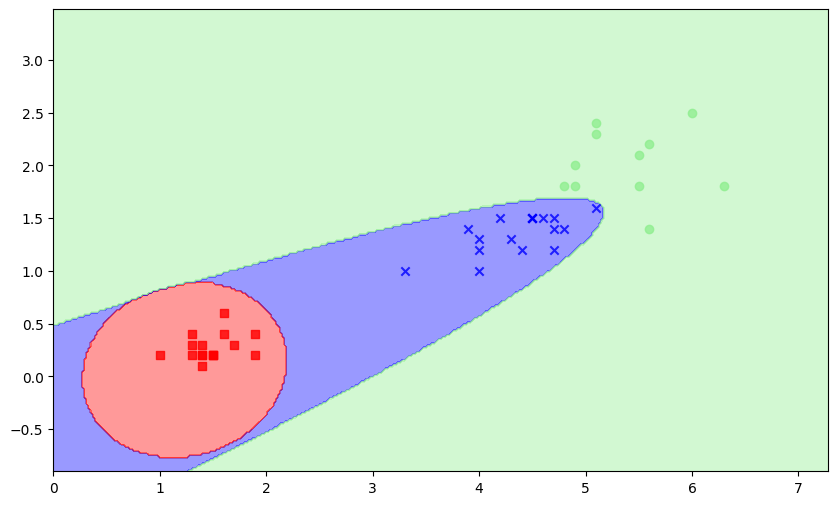

In [11]:
plot_decision_regions(X_test, Y_test, qda)

### Решение методом логистической регрессии

In [12]:
reg = LogisticRegression()
reg.fit(X_train, Y_train)

print('Точность на тренировочных данных {:.2f} %'.format(100*reg.score(X_train, Y_train)))
print('Точность на тестовых данных {:.2f} %'.format(100*reg.score(X_test, Y_test)))

Точность на тренировочных данных 97.14 %
Точность на тестовых данных 97.78 %


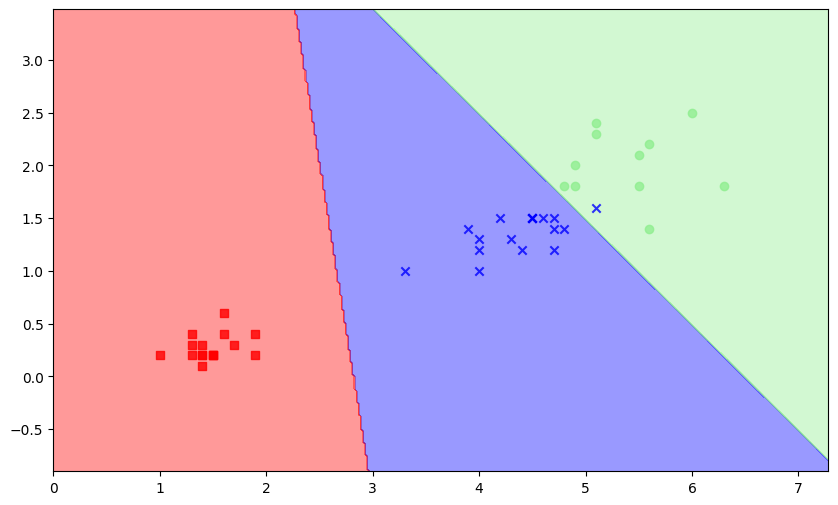

In [13]:
plot_decision_regions(X_test, Y_test, reg)

### Решение методом SVM используя линейное ядро

In [14]:
svml = SVC(kernel='linear')
svml.fit(X_train, Y_train)

print('Точность на тренировочных данных {:.2f} %'.format(100*svml.score(X_train, Y_train)))
print('Точность на тестовых данных {:.2f} %'.format(100*svml.score(X_test, Y_test)))

Точность на тренировочных данных 97.14 %
Точность на тестовых данных 97.78 %


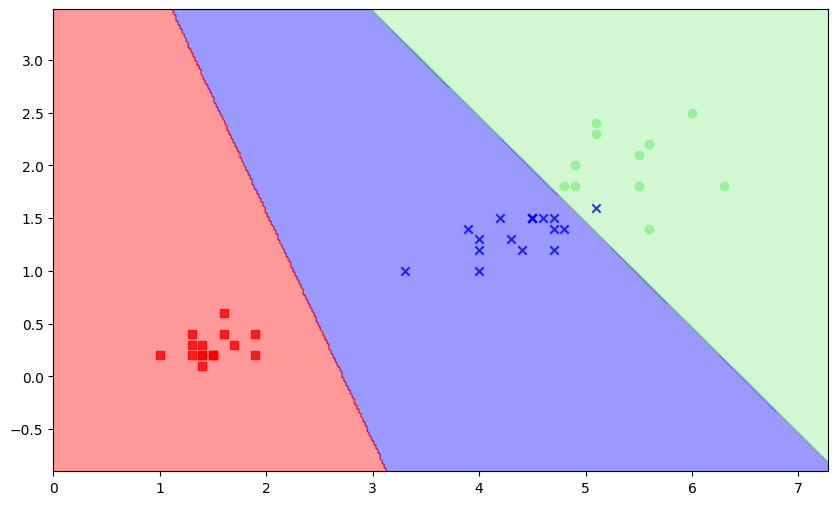

In [15]:
plot_decision_regions(X_test, Y_test, svml)

### Решение методом SVM используя квадратичное ядро

In [16]:
svmq = SVC(kernel='poly', degree=2)
svmq.fit(X_train, Y_train)

print('Точность на тренировочных данных {:.2f} %'.format(100*svmq.score(X_train, Y_train)))
print('Точность на тестовых данных {:.2f} %'.format(100*svmq.score(X_test, Y_test)))

Точность на тренировочных данных 97.14 %
Точность на тестовых данных 97.78 %


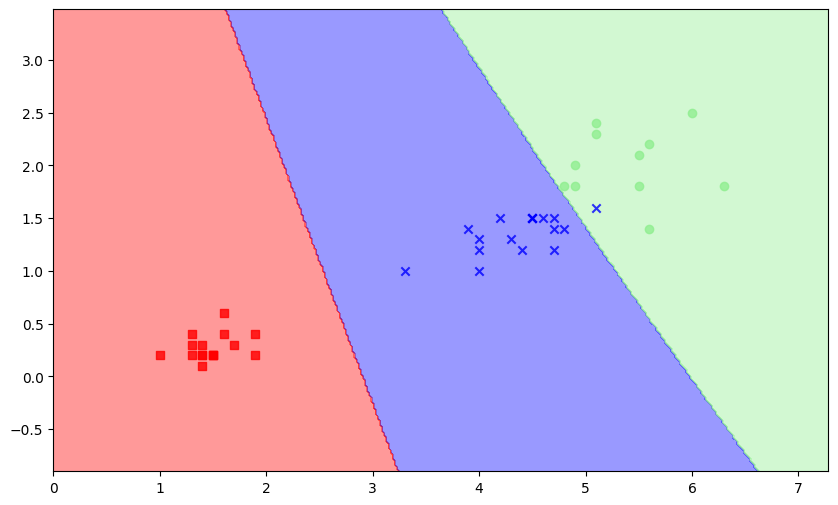

In [17]:
plot_decision_regions(X_test, Y_test, svmq)

## Задание 3

### Подготовка данных

берем все переменные

In [18]:
X3 = iris[['petal length (cm)', 'petal width (cm)', 'sepal length (cm)', 'sepal width (cm)']].values
Y3, unique_classes3 = pd.factorize(iris['class'])
X3_train, X3_test, Y3_train, Y3_test = train_test_split(X3, Y3, test_size=.3, random_state=0)

### Визуализация


линейный дискриминант

In [19]:
lda = LinearDiscriminantAnalysis()
lda.fit(X3_train, Y3_train)

print('Точность на тренировочных данных {:.2f} %'.format(100*lda.score(X3_train, Y3_train)))
print('Точность на тестовых данных {:.2f} %'.format(100*lda.score(X3_test, Y3_test)))

def plot_decision_regions_4D(X, Y, classifier, feature_names, test_idx=None, resolution=0.02):
  markers = ('s', 'x', 'o')
  colors = ('red', 'blue', 'lightgreen')
  Z = classifier.predict(X)

  fig, axs = plt.subplots(2, 3, figsize=(15, 10))
  axs = axs.flatten()

  plot_idx = 0

  for i in range(X.shape[1]):
    for j in range(i+1, X.shape[1]):
      ax = axs[plot_idx]

      for point_idx in range(len(X)):
        true = Y[point_idx]
        guess = Z[point_idx]
        clr = colors[true]
        mrk = markers[guess]

        ax.scatter(x= X[point_idx, i],
                   y= X[point_idx, j],
                   color= clr,
                   marker= mrk)

      ax.set_xlabel(feature_names[i])
      ax.set_ylabel(feature_names[j])

      plot_idx += 1

Точность на тренировочных данных 98.10 %
Точность на тестовых данных 97.78 %


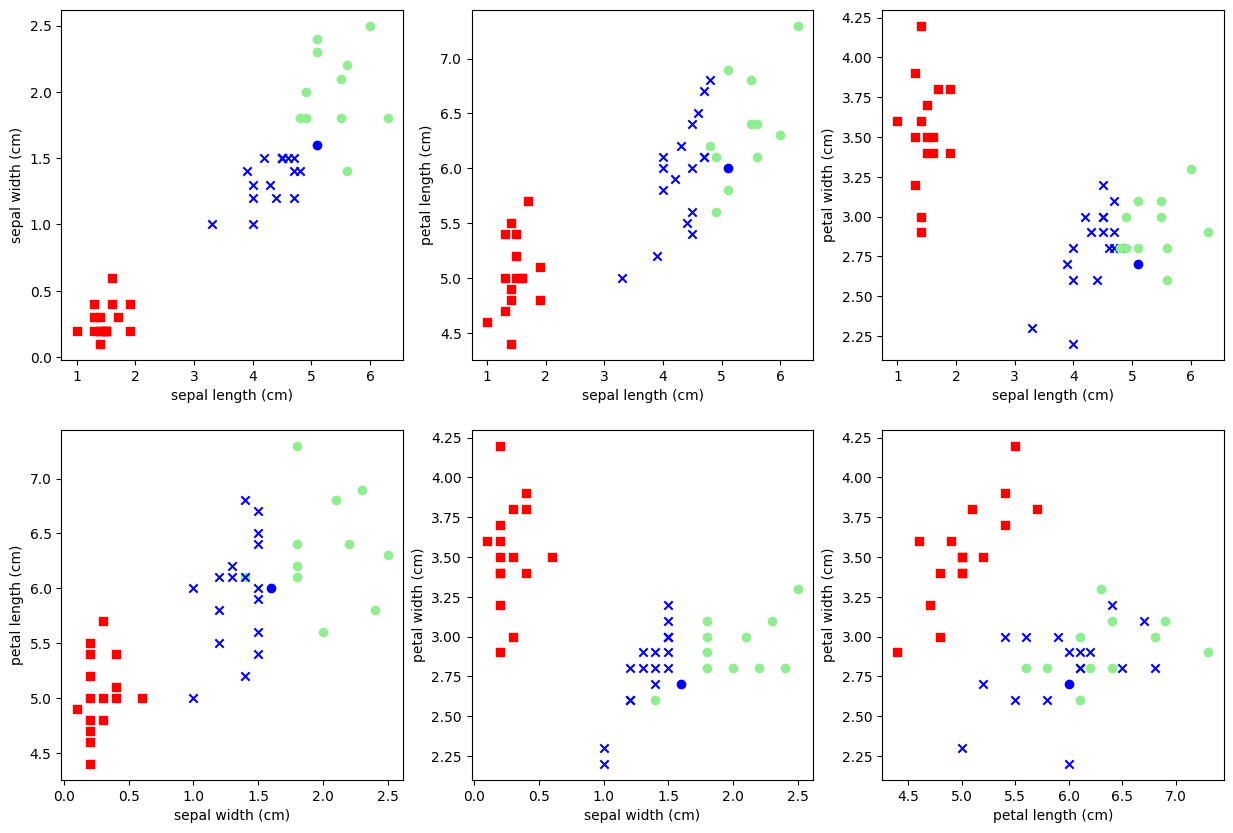

In [20]:
plot_decision_regions_4D(X3_test, Y3_test, lda, iris.columns[:-1])

## Задание 4

### Реализация метода использующего оценку ковариационных матриц и средних

In [21]:
class QuadraticDiscriminant:
    def __init__(self):
        self.means = {}
        self.covariances = {}
        self.priors = {}

    def fit(self, X, Y):        
        for c in np.unique(Y):
            X_c = X[Y == c] # Выборка объектов
            self.means[c] = np.mean(X_c, axis=0) # Вычисление среднего
            self.covariances[c] = np.cov(X_c.T) # Вычисление ковариационной матрицы
            self.priors[c] = X_c.shape[0] / X.shape[0] # Вычисление априорной вероятности

        return self

    def predict(self, X):
        classes = list(self.means.keys())
        predictions = []
        for x in X:
            scores = []
            for c in classes:
                diff = x - self.means[c] # Разность между вектором x и средним класса c
                det_cov = np.linalg.det(self.covariances[c]) # Вычисление детерминанта ковариационной матрицы
                inv_cov = np.linalg.inv(self.covariances[c]) # Вычисление обратной матрицы
                quad_form = np.dot(np.dot(diff.T, inv_cov), diff) # Вычисление квадратичной формы
                
                # Вычисление значения квадратичной разделяющей функции
                score = -0.5 * quad_form - 0.5 * np.log(det_cov) + np.log(self.priors[c])
                scores.append(score)
            
            # Выбор класса с максимальным значением дискриминантной функции
            predictions.append(classes[np.argmax(scores)])
        
        return np.array(predictions)

    def score(self, X, Y):
        Y_pred = self.predict(X)
        accuracy = np.mean(Y_pred == Y)
        return accuracy

### Решение методом оценки ковариационных матриц и средних

In [22]:
qd = QuadraticDiscriminant()
qd.fit(X_train, Y_train)

print('Точность на тренировочных данных {:.2f} %'.format(100*qd.score(X_train, Y_train)))
print('Точность на тестовых данных {:.2f} %'.format(100*qd.score(X_test, Y_test)))

Точность на тренировочных данных 96.19 %
Точность на тестовых данных 100.00 %


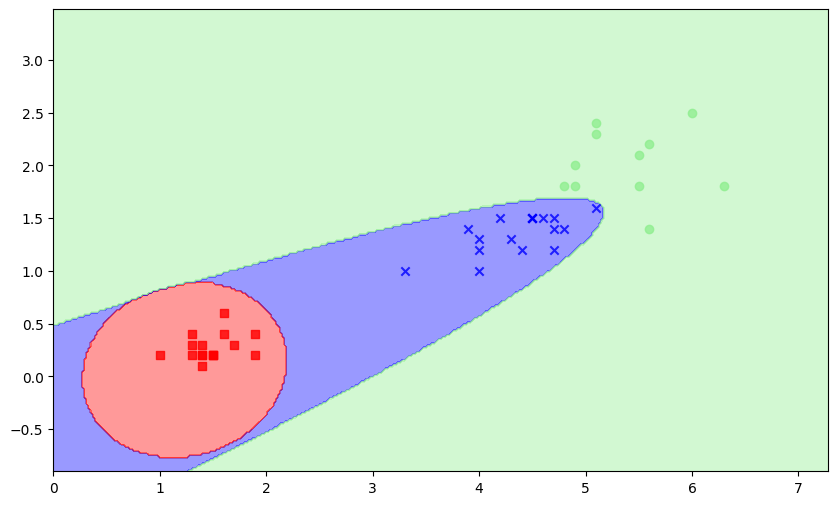

In [23]:
plot_decision_regions(X_test, Y_test, qd)

Точность на тренировочных данных 96.19 %
Точность на тестовых данных 100.00 %


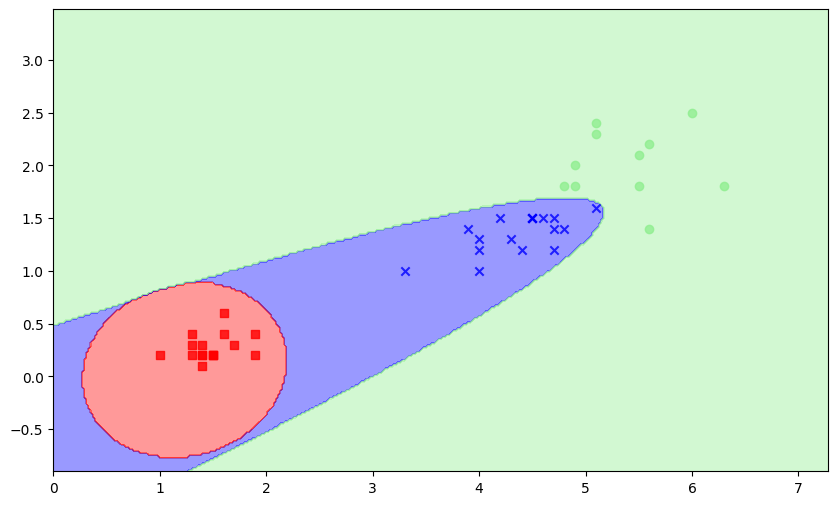

In [24]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, Y_train)

print('Точность на тренировочных данных {:.2f} %'.format(100*qda.score(X_train, Y_train)))
print('Точность на тестовых данных {:.2f} %'.format(100*qda.score(X_test, Y_test)))

plot_decision_regions(X_test, Y_test, qda)